No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:numerical_palette
Legend {'title': 'numerical_palette', 'palette': 'numerical_palette', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'numerical_palette', 'palette': 'numerical_palette', 'enabled': True, 'geom': 'funkyrect'} did not contain labels, inferring from the geom.
Legend {'title': 'numerical_palette', 'palette': 'numerical_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'numerical_palette', 'palette': 'numerical_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]} did not contain color, inferr

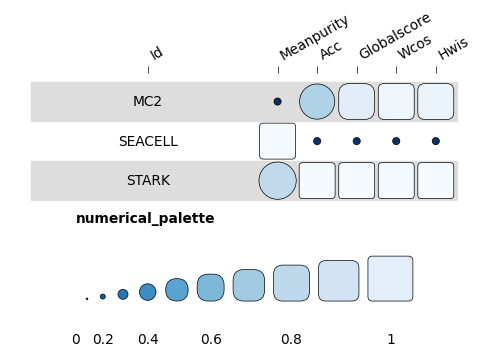

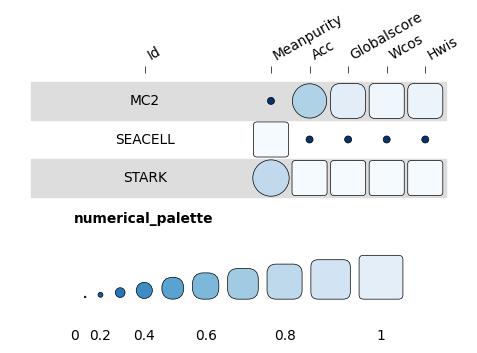

In [14]:
import pandas as pd
import numpy as np
import funkyheatmappy

# ==========================================
# 第一步：模拟你目前的 3 个 CSV 格式的数据
# ==========================================
# 假设每个 CSV 有 5 个指标列。这里我用字典模拟读取 CSV 的结果。
# 实际操作中，你会用 pd.read_csv('tech1.csv') 等代替。

CSV_FILES = {
    'MC2': '/Users/ckw/warehouse/metacell/stark/mc2.csv',
    'SEACELL': '/Users/ckw/warehouse/metacell/stark/seacell.csv',
    'STARK': '/Users/ckw/warehouse/metacell/stark/stark.csv'
}
data_tech = [pd.read_csv(files) for files in CSV_FILES.values()]
# 加上 .to_frame().T 将 Series 转回单行 DataFrame，确保 concat 按行拼接
data_tech = [df.mean(0).to_frame().T for df in data_tech]
for i,k in enumerate(CSV_FILES):
    data_tech[i]['id'] = k


# 将 3 个表纵向合并为一个完整的表格
# 现在的 df 将拥有 3 行 (每个技术一行) 和 6 列 (id + 5个指标)
df_main = pd.concat(data_tech, ignore_index=True)

# 调整列的顺序，把 id 放到第一列（这是一个好习惯）
cols = ['id', 'mean_purity', 'acc', 'global_score', 'wcos', 'hwis']
df_main = df_main[cols]
funkyheatmappy.funky_heatmap(df_main)